## 1. Import libraries

In [15]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

## 2. Set up environments

In [16]:
class SpacedRepetitionEnv(gym.Env):
    """
    Gymnasium environment for RL-based spaced repetition scheduling.

    State  : (N, 3) matrix flattened → [R_0, k_0, Δt_0, R_1, k_1, Δt_1, ...]
    Action : integer i ∈ {0, ..., N-1}  (chapter to study today)
    Reward : mixed reward controlled by alpha
             - non-terminal: (1 - alpha) * mean_retention_t
             - terminal:      mean_retention_T  (full signal on exam day)
    Episode: T days (fixed horizon)

    alpha=0 → pure dense reward (cumulative retention)
    alpha=1 → pure terminal reward (exam-day retention only)
    """

    def __init__(self, N: int = 5, T: int = 30, h0: float = 1.0, s: float = 2.0, alpha: float = 0.5):
        super().__init__()
        self.N = N
        self.T = T
        self.h0 = h0
        self.s = s
        self.h_max = T / 2.0
        self.alpha = alpha          # 0=dense only, 1=terminal only

        low  = np.zeros(N * 3, dtype=np.float32)
        high = np.tile([1.0, float(T), float(T)], N).astype(np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space      = spaces.Discrete(N)

        self._retention_arr: np.ndarray
        self._k_arr:         np.ndarray
        self._delta_t_arr:   np.ndarray
        self._day:           int

    # ------------------------------------------------------------------
    # Core helpers
    # ------------------------------------------------------------------

    def _half_life(self, k: float) -> float:
        """h(k) = min(h0 · s^sqrt(k), h_max)"""
        if k == 0:
            return 0.0
        return float(np.clip(self.h0 * (self.s ** np.sqrt(k)), 0.0, self.h_max))

    def _retention(self, k: float, delta_t: float) -> float:
        """R = 2^(-Δt / h(k));  R = 0 if never studied (k=0)."""
        if k == 0:
            return 0.0
        h = self._half_life(k)
        return float(2.0 ** (-delta_t / h))

    def _recompute_retentions(self) -> None:
        for i in range(self.N):
            self._retention_arr[i] = self._retention(self._k_arr[i], self._delta_t_arr[i])

    def _get_obs(self) -> np.ndarray:
        obs = np.empty(self.N * 3, dtype=np.float32)
        for i in range(self.N):
            obs[3 * i]     = self._retention_arr[i]
            obs[3 * i + 1] = float(self._k_arr[i])
            obs[3 * i + 2] = float(self._delta_t_arr[i])
        return obs

    # ------------------------------------------------------------------
    # Gymnasium API
    # ------------------------------------------------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._retention_arr = np.zeros(self.N, dtype=np.float64)
        self._k_arr         = np.zeros(self.N, dtype=np.int32)
        self._delta_t_arr   = np.zeros(self.N, dtype=np.int32)
        self._day           = 0
        return self._get_obs(), {}

    def step(self, action: int):
        assert self.action_space.contains(action)

        i = action

        # --- Transition ---
        self._k_arr[i]         += 1
        self._delta_t_arr[i]    = 0
        self._retention_arr[i]  = 1.0

        for j in range(self.N):
            if j != i:
                self._delta_t_arr[j] += 1
                self._retention_arr[j] = self._retention(self._k_arr[j], self._delta_t_arr[j])

        self._day += 1
        terminated = self._day >= self.T

        mean_ret = float(np.mean(self._retention_arr))

        # Mixed reward:
        #   non-terminal → scale down by (1 - alpha)
        #   terminal     → full mean_ret (dense part + terminal bonus)
        if terminated:
            reward = mean_ret                          # (1-α)·r + α·r = r
        else:
            reward = (1.0 - self.alpha) * mean_ret

        info = {
            "mean_retention":     mean_ret,            # raw, for F̄ metric
            "terminal_retention": mean_ret if terminated else None,
        }

        obs = self._get_obs()
        return obs, reward, terminated, False, info

    def render(self):
        header = f"Day {self._day:3d}/{self.T} │ "
        cols   = [f"Ch{i}: R={self._retention_arr[i]:.3f} k={self._k_arr[i]} Δt={self._delta_t_arr[i]}"
                  for i in range(self.N)]
        print(header + "  ".join(cols))

## 3. Baseline Agents

In [17]:
class RandomAgent:
    """Selects a chapter uniformly at random each day."""
    def __init__(self, N: int):
        self.N = N

    def select_action(self, obs: np.ndarray) -> int:
        return random.randint(0, self.N - 1)


class RoundRobinAgent:
    """Cycles through chapters in fixed order 0, 1, ..., N-1, 0, 1, ..."""
    def __init__(self, N: int):
        self.N = N
        self._ptr = 0

    def reset(self):
        self._ptr = 0

    def select_action(self, obs: np.ndarray) -> int:
        action = self._ptr
        self._ptr = (self._ptr + 1) % self.N
        return action


class GreedyAgent:
    """
    Greedy policy (Hunziker et al. 2019):
    each day, select the chapter that maximises immediate mean retention.
    """
    def __init__(self, N: int, h0: float = 1.0, s: float = 2.0, T: int = 30):
        self.N = N
        self.h0 = h0
        self.s = s
        self.h_max = T / 2.0

    def _half_life(self, k):
        if k == 0:
            return 0.0
        return float(np.clip(self.h0 * (self.s ** np.sqrt(k)), 0.0, self.h_max))

    def _retention(self, k, delta_t):
        if k == 0:
            return 0.0
        h = self._half_life(k)
        return float(2.0 ** (-delta_t / h))

    def select_action(self, obs: np.ndarray) -> int:
        N = self.N
        R    = obs[0::3]   # current retentions
        k    = obs[1::3]   # study counts
        dt   = obs[2::3]   # days since last study

        best_action, best_reward = -1, -1.0
        for i in range(N):
            # Simulate studying chapter i
            new_R = np.empty(N)
            for j in range(N):
                if j == i:
                    new_R[j] = 1.0
                else:
                    new_R[j] = self._retention(k[j], dt[j] + 1)
            reward = float(np.mean(new_R))
            if reward > best_reward:
                best_reward = reward
                best_action = i
        return best_action

## 4. DQN Agent

In [18]:
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)
        return (
            torch.tensor(np.array(obs),      dtype=torch.float32),
            torch.tensor(actions,            dtype=torch.long),
            torch.tensor(rewards,            dtype=torch.float32),
            torch.tensor(np.array(next_obs), dtype=torch.float32),
            torch.tensor(dones,              dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    """
    Permutation-invariant Q-network.

    Each chapter's feature [R_i, k_i, Δt_i] is encoded by a shared MLP (chapter_encoder).
    The concatenated encodings are then passed to a Q-head that outputs Q(s, a=i) per chapter.

    Because chapter_encoder weights are shared across all chapters, the network
    treats every chapter equivalently — "study the chapter with lowest retention"
    generalises across all N positions without learning each position separately.
    """
    def __init__(self, N: int, T: int, enc_dim: int = 64, head_dim: int = 128):
        super().__init__()
        self.N = N
        self.T = T

        # Shared encoder: maps [R_i, k_i, Δt_i] → enc_dim for every chapter
        self.chapter_encoder = nn.Sequential(
            nn.Linear(3, enc_dim),
            nn.ReLU(),
            nn.Linear(enc_dim, enc_dim),
            nn.ReLU(),
        )

        # Q-head: concatenated chapter encodings → Q value per chapter
        self.q_head = nn.Sequential(
            nn.Linear(enc_dim * N, head_dim),
            nn.ReLU(),
            nn.Linear(head_dim, N),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, N*3)
        batch = x.size(0)

        # Normalise k and Δt to [0, 1] so all inputs live on a similar scale
        norm = x.clone()
        norm[:, 1::3] = norm[:, 1::3] / self.T   # k_i  / T
        norm[:, 2::3] = norm[:, 2::3] / self.T   # Δt_i / T

        # (batch, N*3) → (batch, N, 3)
        chapters = norm.view(batch, self.N, 3)

        # Apply shared encoder to each chapter independently: (batch, N, enc_dim)
        encoded = self.chapter_encoder(chapters)

        # Flatten and compute Q values: (batch, N)
        return self.q_head(encoded.flatten(1))


class DQNAgent:
    def __init__(
        self,
        N: int,
        T: int,
        lr: float          = 5e-4,
        gamma: float       = 0.99,
        eps_start: float   = 1.0,
        eps_end: float     = 0.05,
        eps_decay: int     = 20_000,  # slower decay → more exploration before exploit
        buffer_size: int   = 50_000,
        batch_size: int    = 128,
        target_update: int = 500,     # less frequent sync → more stable target
    ):
        self.N             = N
        self.T             = T
        self.gamma         = gamma
        self.eps_start     = eps_start
        self.eps_end       = eps_end
        self.eps_decay     = eps_decay
        self.batch_size    = batch_size
        self.target_update = target_update

        self.policy_net = QNetwork(N, T)
        self.target_net = QNetwork(N, T)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_size)
        self.steps     = 0

    def _epsilon(self) -> float:
        progress = min(self.steps / self.eps_decay, 1.0)
        return self.eps_end + (self.eps_start - self.eps_end) * (1.0 - progress)

    def select_action(self, obs: np.ndarray) -> int:
        if random.random() < self._epsilon():
            return random.randint(0, self.N - 1)
        with torch.no_grad():
            q = self.policy_net(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
            return int(q.argmax(dim=1).item())

    def push(self, obs, action, reward, next_obs, done):
        self.buffer.push(obs, action, reward, next_obs, done)

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None

        obs_b, act_b, rew_b, nobs_b, done_b = self.buffer.sample(self.batch_size)

        q_values = self.policy_net(obs_b).gather(1, act_b.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            # Double DQN: action selected by policy_net, evaluated by target_net
            best_actions = self.policy_net(nobs_b).argmax(dim=1, keepdim=True)
            next_q       = self.target_net(nobs_b).gather(1, best_actions).squeeze(1)
            targets      = rew_b + self.gamma * next_q * (1.0 - done_b)

        loss = nn.functional.mse_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

## 5. Training Loop

In [19]:
def run_episode(env: SpacedRepetitionEnv, agent, train: bool = False) -> dict:
    """
    Run one full episode.
    Returns dict with:
      - F_bar      : mean cumulative retention  (1/T) Σ mean_retention_t
      - terminal_R : mean retention on the final day (exam day)
    """
    obs, _ = env.reset()
    if hasattr(agent, "reset"):
        agent.reset()

    dense_sum  = 0.0
    terminal_R = 0.0

    while True:
        action = agent.select_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        dense_sum += info["mean_retention"]
        if terminated:
            terminal_R = info["terminal_retention"]

        if train and isinstance(agent, DQNAgent):
            done = terminated or truncated
            agent.push(obs, action, reward, next_obs, float(done))
            agent.update()

        obs = next_obs
        if terminated or truncated:
            break

    return {"F_bar": dense_sum / env.T, "terminal_R": terminal_R}


def train_dqn(
    N=5, T=30, h0=1.0, s=2.0,
    alpha=0.5,
    n_episodes=2000,
    eps_decay=20_000,   # steps; increase for sparser reward (larger alpha)
    log_every=200,
    verbose=True,
):
    """
    Train a DQN agent.

    eps_decay guidance:
      alpha=0.0 → 20_000  (dense signal, fast convergence)
      alpha=0.5 → 25_000
      alpha=1.0 → 35_000  (sparse signal, needs longer exploration)
    """
    env   = SpacedRepetitionEnv(N=N, T=T, h0=h0, s=s, alpha=alpha)
    agent = DQNAgent(N=N, T=T, eps_decay=eps_decay)

    f_bars, term_Rs = [], []
    for ep in range(1, n_episodes + 1):
        result = run_episode(env, agent, train=True)
        f_bars.append(result["F_bar"])
        term_Rs.append(result["terminal_R"])

        if verbose and ep % log_every == 0:
            f_avg  = np.mean(f_bars[-log_every:])
            tr_avg = np.mean(term_Rs[-log_every:])
            print(f"Ep {ep:5d} | F̄={f_avg:.4f}  R_T={tr_avg:.4f} | ε={agent._epsilon():.3f}")

    return agent, f_bars, term_Rs


print("=== alpha=0.5 (혼합 보상) ===")
N, T = 5, 30
agent, f_bars, term_Rs = train_dqn(N=N, T=T, alpha=0.5, n_episodes=2000, eps_decay=25_000)

=== alpha=0.5 (혼합 보상) ===
Ep   200 | F̄=0.5479  R_T=0.6681 | ε=0.777
Ep   400 | F̄=0.5801  R_T=0.7164 | ε=0.549
Ep   600 | F̄=0.6043  R_T=0.7387 | ε=0.321
Ep   800 | F̄=0.6197  R_T=0.7581 | ε=0.093
Ep  1000 | F̄=0.6379  R_T=0.7759 | ε=0.050
Ep  1200 | F̄=0.6382  R_T=0.7739 | ε=0.050
Ep  1400 | F̄=0.6366  R_T=0.7743 | ε=0.050
Ep  1600 | F̄=0.6385  R_T=0.7753 | ε=0.050
Ep  1800 | F̄=0.6389  R_T=0.7761 | ε=0.050
Ep  2000 | F̄=0.6389  R_T=0.7728 | ε=0.050


## 6. Evaluation vs Baselines

In [20]:
def evaluate(agent, N, T, h0=1.0, s=2.0, n_eval=50) -> dict:
    """
    Evaluate agent with greedy policy (ε=0).
    Returns F̄ and terminal retention — both computed from raw retention values,
    independent of alpha (alpha only affects training reward, not these metrics).
    """
    env = SpacedRepetitionEnv(N=N, T=T, h0=h0, s=s, alpha=0.0)
    f_bars, term_Rs = [], []

    for _ in range(n_eval):
        if isinstance(agent, DQNAgent):
            orig_eps_end, orig_steps = agent.eps_end, agent.steps
            agent.eps_end = 0.0
            agent.steps   = agent.eps_decay   # force ε → 0
        result = run_episode(env, agent, train=False)
        if isinstance(agent, DQNAgent):
            agent.eps_end = orig_eps_end
            agent.steps   = orig_steps
        f_bars.append(result["F_bar"])
        term_Rs.append(result["terminal_R"])

    return {
        "F_bar_mean": np.mean(f_bars),   "F_bar_std": np.std(f_bars),
        "termR_mean": np.mean(term_Rs),  "termR_std": np.std(term_Rs),
    }


def compare_agents(N=5, T=30, h0=1.0, s=2.0, alpha=0.5, n_train=2000, n_eval=50):
    dqn_agent, _, _ = train_dqn(N=N, T=T, h0=h0, s=s, alpha=alpha,
                                 n_episodes=n_train, eps_decay=25_000)

    baselines = {
        "Random":      RandomAgent(N),
        "Round Robin": RoundRobinAgent(N),
        "Greedy":      GreedyAgent(N, h0=h0, s=s, T=T),
        "DQN":         dqn_agent,
    }

    print(f"\n{'='*65}")
    print(f"N={N}, T={T}, T/N={T/N:.1f}, α={alpha}  (eval {n_eval} eps, ε=0)")
    print(f"{'='*65}")
    print(f"  {'Agent':<12s}  {'F̄ (cumul)':>14s}  {'R_T (exam day)':>16s}")
    print(f"  {'-'*12}  {'-'*14}  {'-'*16}")

    results = {}
    for name, ag in baselines.items():
        m = evaluate(ag, N, T, h0, s, n_eval)
        results[name] = m
        print(f"  {name:<12s}  {m['F_bar_mean']:.4f}±{m['F_bar_std']:.4f}    "
              f"{m['termR_mean']:.4f}±{m['termR_std']:.4f}")
    return results


results = compare_agents(N=5, T=30, alpha=0.5, n_train=2000, n_eval=50)

Ep   200 | F̄=0.5516  R_T=0.6773 | ε=0.777
Ep   400 | F̄=0.5839  R_T=0.7237 | ε=0.549
Ep   600 | F̄=0.6039  R_T=0.7423 | ε=0.321
Ep   800 | F̄=0.6251  R_T=0.7587 | ε=0.093
Ep  1000 | F̄=0.6364  R_T=0.7770 | ε=0.050
Ep  1200 | F̄=0.6370  R_T=0.7757 | ε=0.050
Ep  1400 | F̄=0.6367  R_T=0.7735 | ε=0.050
Ep  1600 | F̄=0.6381  R_T=0.7749 | ε=0.050
Ep  1800 | F̄=0.6374  R_T=0.7736 | ε=0.050
Ep  2000 | F̄=0.6389  R_T=0.7764 | ε=0.050

N=5, T=30, T/N=6.0, α=0.5  (eval 50 eps, ε=0)
  Agent             F̄ (cumul)    R_T (exam day)
  ------------  --------------  ----------------
  Random        0.5387±0.0230    0.6570±0.0590
  Round Robin   0.6480±0.0000    0.7884±0.0000
  Greedy        0.6480±0.0000    0.7884±0.0000
  DQN           0.6380±0.0000    0.7574±0.0000


## 7. Learning Curve Visualization

Ep   200 | F̄=0.5495  R_T=0.6732 | ε=0.777
Ep   400 | F̄=0.5810  R_T=0.7170 | ε=0.549
Ep   600 | F̄=0.6080  R_T=0.7421 | ε=0.321
Ep   800 | F̄=0.6274  R_T=0.7643 | ε=0.093
Ep  1000 | F̄=0.6398  R_T=0.7799 | ε=0.050
Ep  1200 | F̄=0.6408  R_T=0.7820 | ε=0.050
Ep  1400 | F̄=0.6414  R_T=0.7817 | ε=0.050
Ep  1600 | F̄=0.6406  R_T=0.7794 | ε=0.050
Ep  1800 | F̄=0.6404  R_T=0.7763 | ε=0.050
Ep  2000 | F̄=0.6410  R_T=0.7816 | ε=0.050


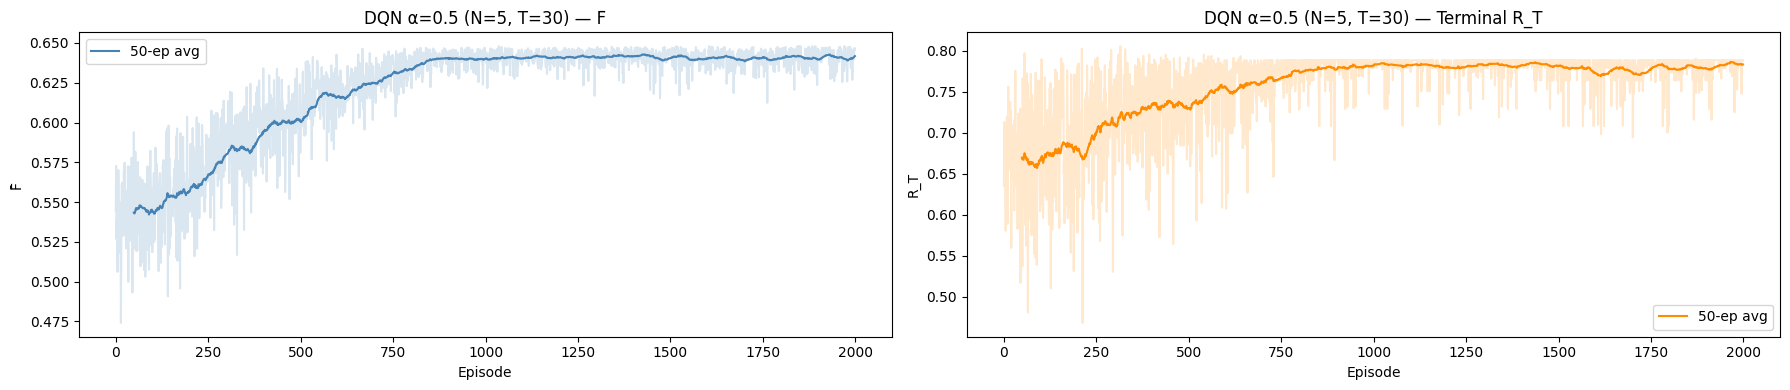

In [21]:
def plot_learning_curve(f_bars, term_Rs=None, window=50, title="DQN Learning Curve"):
    smoothed_f = np.convolve(f_bars, np.ones(window) / window, mode="valid")
    xs = range(window - 1, len(f_bars))

    n_plots = 2 if term_Rs is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(9 * n_plots // 1, 4))
    if n_plots == 1:
        axes = [axes]

    axes[0].plot(f_bars, alpha=0.2, color="steelblue")
    axes[0].plot(xs, smoothed_f, color="steelblue", label=f"{window}-ep avg")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("F̄")
    axes[0].set_title(f"{title} — F̄")
    axes[0].legend()

    if term_Rs is not None:
        smoothed_t = np.convolve(term_Rs, np.ones(window) / window, mode="valid")
        axes[1].plot(term_Rs, alpha=0.2, color="darkorange")
        axes[1].plot(xs, smoothed_t, color="darkorange", label=f"{window}-ep avg")
        axes[1].set_xlabel("Episode")
        axes[1].set_ylabel("R_T")
        axes[1].set_title(f"{title} — Terminal R_T")
        axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_alpha_comparison(N=5, T=30, h0=1.0, s=2.0, n_train=2000):
    """
    Train DQN under α ∈ {0, 0.5, 1} and compare learning curves + eval metrics.
    Each alpha is trained exactly once (no duplicate training).
    """
    alphas     = [0.0,        0.5,         1.0       ]
    eps_decays = [20_000,     25_000,      35_000    ]  # sparser reward needs more exploration
    labels     = ["α=0",     "α=0.5",     "α=1"     ]
    colors     = ["steelblue","darkorange","seagreen" ]

    # --- Train once per alpha, store everything ---
    trained = {}   # alpha → (agent, f_bars, term_Rs)
    for alpha, eps_decay, label in zip(alphas, eps_decays, labels):
        print(f"\n--- Training {label} ---")
        ag, fb, tr = train_dqn(N=N, T=T, h0=h0, s=s,
                                alpha=alpha, n_episodes=n_train,
                                eps_decay=eps_decay, log_every=n_train // 5)
        trained[alpha] = (ag, fb, tr)

    # --- Compute baseline values dynamically ---
    baseline_agents = {
        "Round Robin": RoundRobinAgent(N),
        "Random":      RandomAgent(N),
    }
    bl_vals = {}
    for name, ag in baseline_agents.items():
        m = evaluate(ag, N, T, h0, s, n_eval=100)
        bl_vals[name] = (m["F_bar_mean"], m["termR_mean"])

    # --- Plot 1: Learning curves (F̄) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    window = 50
    for alpha, label, color in zip(alphas, labels, colors):
        _, fb, tr = trained[alpha]
        sm_f = np.convolve(fb, np.ones(window) / window, mode="valid")
        sm_t = np.convolve(tr, np.ones(window) / window, mode="valid")
        xs   = range(window - 1, len(fb))
        axes[0].plot(xs, sm_f, label=label, color=color)
        axes[1].plot(xs, sm_t, label=label, color=color)

    for ax, (bl_key, bl_idx, ylabel) in zip(
        axes,
        [("Round Robin", 0, "F̄"), ("Round Robin", 1, "R_T (exam day)")]
    ):
        for name, vals in bl_vals.items():
            ax.axhline(vals[bl_idx], linestyle="--" if name == "Round Robin" else ":",
                       color="gray", linewidth=1, label=name)
        ax.set_xlabel("Episode")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Learning Curve — {ylabel}")
        ax.legend(fontsize=8)

    plt.suptitle(f"N={N}, T={T}, T/N={T/N:.1f}", fontsize=11)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Eval bar chart ---
    f_bar_means, termR_means = [], []
    for alpha in alphas:
        ag, _, _ = trained[alpha]
        m = evaluate(ag, N, T, h0, s, n_eval=50)
        f_bar_means.append(m["F_bar_mean"])
        termR_means.append(m["termR_mean"])

    x = np.arange(len(alphas))
    w = 0.35
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - w / 2, f_bar_means, w, label="F̄ (cumul)",   color="steelblue",  alpha=0.85)
    ax.bar(x + w / 2, termR_means, w, label="R_T (exam)",   color="darkorange", alpha=0.85)

    # Baseline lines
    for name, vals in bl_vals.items():
        ls = "--" if name == "Round Robin" else ":"
        ax.axhline(vals[0], linestyle=ls, color="steelblue", linewidth=1, alpha=0.5)
        ax.axhline(vals[1], linestyle=ls, color="darkorange", linewidth=1, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Retention (ε=0 greedy eval)")
    ax.set_title(f"DQN Eval by α  (N={N}, T={T})")
    ax.legend()
    y_min = min(f_bar_means + termR_means) - 0.05
    ax.set_ylim(max(0.0, y_min), 1.0)
    plt.tight_layout()
    plt.show()


# 기본 학습 곡선 확인 (alpha=0.5)
_, long_f, long_t = train_dqn(N=5, T=30, alpha=0.5, n_episodes=2000, eps_decay=25_000)
plot_learning_curve(long_f, long_t, title="DQN α=0.5 (N=5, T=30)")